# Model Selection and Evaluation - Part 2

## Exercise 3 - Cross Validation

In the previous activity, we made the classic mistake of tuning our model using our test set. This tends to give misleadingly optimistic predictions about how well we will do on unobserved data. Remember that we carefully picked our hyperparameter values to do as well as possible *on our held-out data*. We shouldn't be surprised when our model performs better on that data than on unobserved data. This problem is particularly acute if our data set is small.

The traditional solution is to divide our data into three disjoint sets: **training**, **validation**, and **testing**:
* The **training** set is used to fit the model.
* The **validation** set is used to evaluate models for the purpose of hyperparameter selection. 
* The **test** set is kept in a locked room guarded by jaguars. We only look at the testing set ONCE, when we have finalized our model. That way our performance on the test set gives us an unbiased estimate of our generalization error.

This traditional approach is fine if we have a lot of data to work with. If the data set is small, we are faced with a painful dilemma: More validation data means better model selection. More testing data means more accurate model evaluation. More training data means better models. Any data we use for one purpose can't be used for the others.

**Cross validation** is one way to use limited data more effectively.  The cells below walk us through an example of using cross validation for hyperparameter tuning.

In [1]:
# We need to reimport and reload everything...

import numpy as np
import matplotlib.pyplot as plt
import sprinkle_data

from sklearn.tree import DecisionTreeRegressor

# Grab our training data
source = sprinkle_data.SprinkleDataSource()
X, y = source.gen_data(100, seed=2)

# Split our data into a training and testing set...
split_point = int(X.shape[0] * .8) # Use 80% of the data to train the model

X_train = X[:split_point, :]
y_train = y[:split_point]

X_test = X[split_point:, :] # This data will ONLY be used for final evaluation.
y_test = y[split_point:]

The following cell shows how we can use the scikit-learn `KFold` class to automatically split up our training data for k-fold cross validation. Take a minute to read through this code to make sure you understand what's going on.

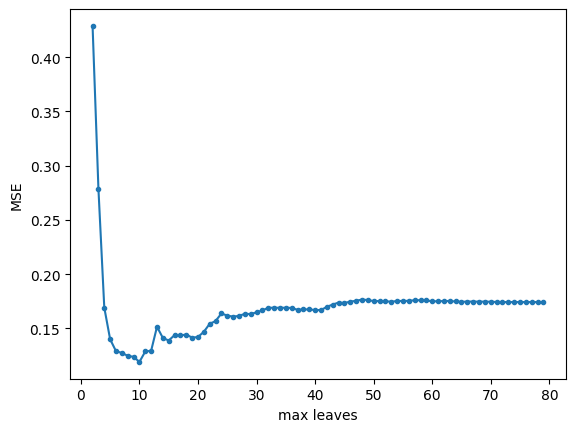

In [2]:
from sklearn.model_selection import KFold

folds = 10
max_max_leaves = y_train.size
kf = KFold(n_splits=folds)

mses = np.zeros((folds, max_max_leaves - 2)) # (can't have 0 or 1 leaves)

# Loop over all of the hyperparameter settings
for max_leaves in range(2, max_max_leaves):
    
    k = 0
    
    # Evaluate each one K-times
    for train_index, val_index in kf.split(X_train):
        X_tr, X_val = X_train[train_index, :], X_train[val_index, :]
        y_tr, y_val = y_train[train_index], y_train[val_index]

        tree = DecisionTreeRegressor(max_leaf_nodes=max_leaves)
        tree.fit(X_tr, y_tr)
        
        y_val_predict = tree.predict(X_val)
        mses[k, max_leaves - 2] = np.sum((y_val - y_val_predict)**2) / y_val.size
        
        k += 1
        
# Average across the k folds
mse_avg = np.mean(mses, axis=0)

plt.plot(np.arange(2, max_max_leaves), mse_avg, '.-')
plt.xlabel('max leaves')
plt.ylabel('MSE')
plt.show()

If we are real experts in scikit-learn, we can automate some of this by using the `cross_val_score` function:  

(There are also library routines for [automating the entire process of hyperparameter tuning](https://scikit-learn.org/stable/modules/grid_search.html).) 

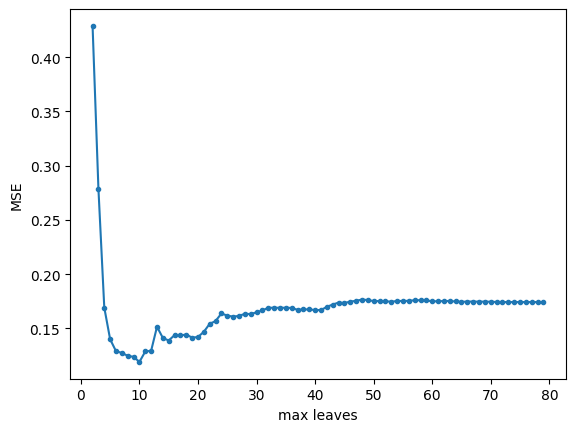

In [3]:
# THIS CODE CELL ACCOMPLISHES THE SAME THING AS THE PREVIOUS ONE.

from sklearn.model_selection import cross_val_score

mses = np.zeros((folds,max_max_leaves - 2))

# Loop over all of the hyperparameter settings
for leaves in range(2, max_max_leaves):
    tree = DecisionTreeRegressor(max_leaf_nodes=leaves)
    
    # Returns an array of cross validation results.
    mses[:, leaves - 2] = -cross_val_score(tree, X_train, y_train, 
                                         cv=folds, scoring='neg_mean_squared_error')
    
mse_avg = np.mean(mses, axis=0)

plt.xlabel('max leaves')
plt.ylabel('MSE')
plt.plot(np.arange(2, max_max_leaves), mse_avg, '.-')
plt.show()



### Question

* Based on the results above, what is the most promising hyperparameter value?

10

Now that we have a value for our hyperparameter, let's train our final model on the *full* training set and use our locked-away testing set to predict model performance.

In [4]:
tree = DecisionTreeRegressor(max_leaf_nodes=10) # Put your best hyperparameter here!

# Train using ALL the training data
tree.fit(X_train, y_train)

# Test on held-out testing data
y_test_predict = tree.predict(X_test)
mse = np.sum((y_test - y_test_predict)**2) / y_test.size

print("Predicted MSE: {:.4f}".format(mse))

Predicted MSE: 0.1280


Since none of the data we are testing on here was used *in any way* to design or fit the model, this value should give us an unbiased estimate of our generalization error.  Let's try testing on some new unobserved data to see how good our estimate is:

In [5]:
# Let's see how we do on unobserved data... 
X_new, y_new = source.gen_data(100000, seed=100)
y_new_predict = tree.predict(X_new)
mse = np.sum((y_new - y_new_predict)**2) / y_new.size
print("MSE: {:.4f}".format(mse))

MSE: 0.1144


### Questions

Take a look back at the results from Exercise 2 and answer the following questions:

* Did the cross validation approach improve our results in terms of *model selection* (i.e. did we end up with a better model)?  Justify your answer.
* Did maintaining a proper test set improve our results in terms of *model evaluation* (i.e. did we make a more accurate prediction about our generalization error)?  Justify your answer.

* Yes, we did end up with a better model because we ended up with an MSE closer to what our model predicted the MSE to be when predicting the test set.
* Yes, because our models predicted MSE, when maintaining a proper test set in *Exercise 3*, closer to the actual MSE calculated when we used our unobserved data when compared to our model in *Exercise 2*

## Exercise 4 - Settling the Question

The end of the last exercise was slightly unsatisfying.  Our clean test set predicted .1280 when the truth was .1144.  In Exercise 2 we predicted .1016 when the truth was .1377.  The clean estimate was closer, but not by much, and it missed in the opposite direction.  It doesn't seem like an obvious win.

The trouble is that our test set holds only 20 points, so any single test-set estimate is very noisy.  Here that noise is larger than the effect we are trying to see, and one experiment cannot separate the two.

The real difference between the two protocols is not primarily the *size* of the error on any one run.  It is the *direction*.  Tuning on the test set and then reporting that score is **systematically** optimistic, because we deliberately kept whichever setting happened to look best on those particular 20 points.  A clean test set is wrong in a *random* direction: it was pessimistic for us here, and it will be optimistic just as often.  Those estimates may not be as precise as we would like, but at least they are unbiased.

Averaging many runs is what makes this visible.  The cell below runs the whole lab 60 times on freshly generated data and compares the two protocols:

1. **Exercise 2 protocol.**  Tune `max_leaf_nodes` against the test set, then report that same test score.
2. **Exercise 3 protocol.**  Tune by cross validation on the training data alone, then report the score from a test set we never touched.

In both cases we compare the number we would have reported against the true error of the model we selected, measured on a large fresh sample.

In [6]:
from sklearn.model_selection import KFold


def mse(model, X, y):
    return np.mean((y - model.predict(X))**2)


def one_experiment(seed, folds=10, max_leaves=40, n_data=100,
                   train_frac=.8, n_fresh=20000):
    """ Run the entire lab once on freshly drawn data.

    Returns the number we would report under each protocol, along with the
    true error of the model that protocol selected.
    """
    X, y = source.gen_data(n_data)
    split_point = int(n_data * train_frac)
    X_train, y_train = X[:split_point], y[:split_point]
    X_test, y_test = X[split_point:], y[split_point:]
    X_fresh, y_fresh = source.gen_data(n_fresh)

    grid = np.arange(2, max_leaves + 1)
    trees = [DecisionTreeRegressor(max_leaf_nodes=int(g)).fit(X_train, y_train)
             for g in grid]

    # Protocol 1 (Exercise 2): keep the setting with the best TEST score,
    # and report that score.
    test_scores = np.array([mse(t, X_test, y_test) for t in trees])
    tuned_on_test = int(np.argmin(test_scores))

    # Protocol 2 (Exercise 3): keep the setting chosen by cross validation
    # over the training data alone, and report the untouched test set.
    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)
    cv_scores = np.zeros(grid.size)
    for i, leaves in enumerate(grid):
        cv_scores[i] = np.mean(
            [mse(DecisionTreeRegressor(max_leaf_nodes=int(leaves)).fit(
                X_train[a], y_train[a]), X_train[b], y_train[b])
             for a, b in kf.split(X_train)])
    tuned_by_cv = int(np.argmin(cv_scores))

    return {"tuned_report": test_scores[tuned_on_test],
            "tuned_truth": mse(trees[tuned_on_test], X_fresh, y_fresh),
            "clean_report": mse(trees[tuned_by_cv], X_test, y_test),
            "clean_truth": mse(trees[tuned_by_cv], X_fresh, y_fresh)}


np.random.seed(0)          # so that everyone sees the same numbers
runs = [one_experiment(seed) for seed in range(60)]
avg = {k: np.mean([r[k] for r in runs]) for k in runs[0]}

rows = [("Exercise 2:  tuned on the test set",
         avg["tuned_report"], avg["tuned_truth"]),
        ("Exercise 3:  clean test set",
         avg["clean_report"], avg["clean_truth"])]

print("Averaged over {} runs of the whole experiment:\n".format(len(runs)))
print("  {:36} {:>9} {:>9} {:>9}".format("", "reported", "truth", "error"))
for name, reported, truth in rows:
    print("  {:36} {:9.4f} {:9.4f} {:+9.4f}".format(
        name, reported, truth, reported - truth))

Averaged over 60 runs of the whole experiment:

                                        reported     truth     error
  Exercise 2:  tuned on the test set      0.0975    0.1224   -0.0249
  Exercise 3:  clean test set             0.1170    0.1178   -0.0008


### Questions

* Which protocol gives the more accurate prediction of generalization error, and by how much?
* Look at the `truth` column.  Did cross validation leave us with a better model, or only with a more honest number about the same model?
* What did the honest estimate cost us?

* Exercise 3's protocol gives the more accurate prediction of generalization error. It is only off from the prediction by 0.0008, while using Exercise 2's protocol is much farther from the true value. Exercise 2's prediciton of generalization error is off by 0.0249.
* Yes, cross validation left us with a better model, this can be seen because when using our model to make predictions for our test set we got an MSE value of 0.1170, then after we made predictions on the test set, we created a data-set that the model had not seen before and its predictions netted an MSE of 0.1178.
* It costed us training data. We gave up 20% of our training data to use as the test set instead of using the full data-set to train our model and tune our hyperparameters.